# Taller 11 - CNN
## Vision Artificial con CNNs vs. Machine Learning Clasico
### Juan David Nieto-Sumin Han 


## Configuracion inicial e imports

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.13.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Linea Base - Machine Learning Clasico (Scikit-Learn)

Cargamos Fashion-MNIST y entrenamos varios modelos clasicos. Los modelos clasicos requieren *aplanar* las imagenes 28x28 a un vector de 784 valores con `reshape`, perdiendo asi la estructura espacial 2D.



In [2]:
# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print('Forma original de x_train:', x_train.shape)  # (60000, 28, 28)

x_train_flat = x_train.reshape(len(x_train), -1).astype(np.float32) / 255.0
x_test_flat  = x_test.reshape(len(x_test),  -1).astype(np.float32) / 255.0

print('Forma tras reshape (aplanado):', x_train_flat.shape)  # (60000, 784)

Forma original de x_train: (60000, 28, 28)
Forma tras reshape (aplanado): (60000, 784)


In [3]:
models = {
    'Arbol de Decision'      : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=300, max_depth=20, n_jobs=-1, random_state=42),
    'Gradient Boosted Trees' : HistGradientBoostingClassifier(max_iter=200, max_depth=10, random_state=42),
    'SVC Lineal (LinearSVC)' : LinearSVC(C=1.0, max_iter=2000, dual=False),
    'MLP (256,128)'          : MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',
                                              max_iter=30, solver='adam', random_state=42, verbose=False),
}

sklearn_results = {}

for name, model in models.items():
    print(f'Entrenando {name}...')
    t0 = time.time()
    model.fit(x_train_flat, y_train)
    train_time = time.time() - t0
    y_pred = model.predict(x_test_flat)
    acc = accuracy_score(y_test, y_pred)
    sklearn_results[name] = {'accuracy': acc, 'time_s': train_time}
    print(f'  -> acc = {acc:.4f}  |  tiempo = {train_time:.1f} s')

print('\nResultados finales (Sklearn):')
for name, r in sorted(sklearn_results.items(), key=lambda kv: kv[1]['accuracy'], reverse=True):
    print(f"  {name:25s}  acc={r['accuracy']:.4f}   t={r['time_s']:.1f}s")

Entrenando Arbol de Decision...
  -> acc = 0.7970  |  tiempo = 15.4 s
Entrenando Random Forest...
  -> acc = 0.8755  |  tiempo = 12.6 s
Entrenando Gradient Boosted Trees...
  -> acc = 0.8964  |  tiempo = 44.1 s
Entrenando SVC Lineal (LinearSVC)...
  -> acc = 0.8401  |  tiempo = 48.8 s
Entrenando MLP (256,128)...
  -> acc = 0.8964  |  tiempo = 20.1 s

Resultados finales (Sklearn):
  Gradient Boosted Trees     acc=0.8964   t=44.1s
  MLP (256,128)              acc=0.8964   t=20.1s
  Random Forest              acc=0.8755   t=12.6s
  SVC Lineal (LinearSVC)     acc=0.8401   t=48.8s
  Arbol de Decision          acc=0.7970   t=15.4s


/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


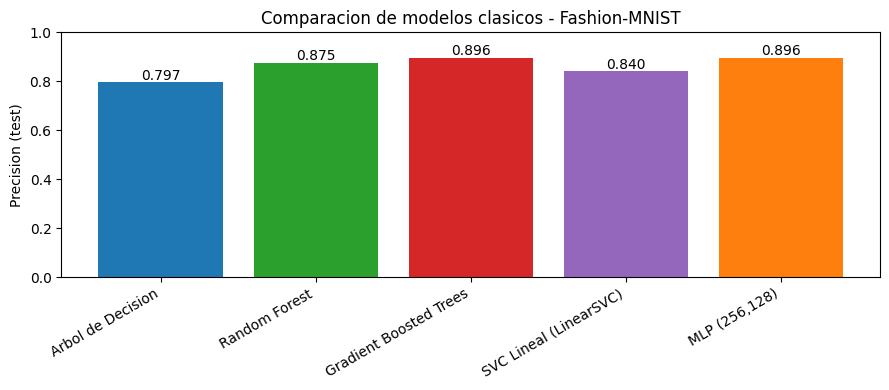

In [4]:

names = list(sklearn_results.keys())
accs  = [sklearn_results[n]['accuracy'] for n in names]

plt.figure(figsize=(9, 4))
plt.bar(names, accs, color=['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Precision (test)')
plt.title('Comparacion de modelos clasicos - Fashion-MNIST')
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

## Preparacion de datos para CNN



In [5]:
(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = keras.datasets.fashion_mnist.load_data()

x_train_cnn = x_train_cnn.astype('float32') / 255.0
x_test_cnn  = x_test_cnn.astype('float32')  / 255.0

x_train_cnn = x_train_cnn[..., tf.newaxis]
x_test_cnn  = x_test_cnn[...,  tf.newaxis]

print('Shape para CNN:', x_train_cnn.shape)

EPOCHS     = 10   
BATCH_SIZE = 64

cnn_results = {}
histories   = {}

Shape para CNN: (60000, 28, 28, 1)


### Helper: callback para medir tiempo por epoca

In [6]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self._t0)

def entrenar_y_evaluar(model, etiqueta):
    timer = EpochTimer()
    t0 = time.time()
    history = model.fit(x_train_cnn, y_train_cnn,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_data=(x_test_cnn, y_test_cnn),
                        callbacks=[timer],
                        verbose=2)
    total = time.time() - t0
    test_loss, test_acc = model.evaluate(x_test_cnn, y_test_cnn, verbose=0)
    train_acc = history.history['accuracy'][-1]
    val_acc   = history.history['val_accuracy'][-1]
    cnn_results[etiqueta] = {
        'test_acc'   : test_acc,
        'train_acc'  : train_acc,
        'val_acc'    : val_acc,
        'tiempo_total': total,
        'tiempo_por_epoca': float(np.mean(timer.times)),
        'parametros' : model.count_params(),
    }
    histories[etiqueta] = history
    print(f'\n>>> {etiqueta}')
    print(f'    test_acc  = {test_acc:.4f}')
    print(f'    train_acc = {train_acc:.4f}  | val_acc = {val_acc:.4f}')
    print(f'    overfitting (train-val) = {train_acc-val_acc:+.4f}')
    print(f'    tiempo medio por epoca  = {np.mean(timer.times):.1f} s')
    print(f'    parametros del modelo   = {model.count_params():,}')
    return history

In [8]:
model_1 = keras.Sequential([
    # ---- Capa Convolucional 1 ----
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

  
     layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
     layers.BatchNormalization(),
     layers.MaxPooling2D((2, 2)),
     layers.Dropout(0.25),


     layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
     layers.BatchNormalization(),
     layers.MaxPooling2D((2, 2)),
     layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model_1.summary()
entrenar_y_evaluar(model_1, 'CNN 1 capa')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_2 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_3 (Bat  (None, 14, 14, 64)       

2026-05-10 21:22:33.737093: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-10 21:22:42.728199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


938/938 - 10s - loss: 0.5827 - accuracy: 0.7943 - val_loss: 0.3507 - val_accuracy: 0.8701 - 10s/epoch - 11ms/step
Epoch 2/10
938/938 - 7s - loss: 0.3732 - accuracy: 0.8647 - val_loss: 0.3314 - val_accuracy: 0.8760 - 7s/epoch - 8ms/step
Epoch 3/10
938/938 - 7s - loss: 0.3314 - accuracy: 0.8802 - val_loss: 0.2805 - val_accuracy: 0.8976 - 7s/epoch - 7ms/step
Epoch 4/10
938/938 - 7s - loss: 0.3038 - accuracy: 0.8901 - val_loss: 0.3528 - val_accuracy: 0.8661 - 7s/epoch - 8ms/step
Epoch 5/10
938/938 - 7s - loss: 0.2893 - accuracy: 0.8970 - val_loss: 0.2643 - val_accuracy: 0.9033 - 7s/epoch - 8ms/step
Epoch 6/10
938/938 - 7s - loss: 0.2743 - accuracy: 0.9006 - val_loss: 0.2461 - val_accuracy: 0.9120 - 7s/epoch - 8ms/step
Epoch 7/10
938/938 - 7s - loss: 0.2695 - accuracy: 0.9028 - val_loss: 0.2414 - val_accuracy: 0.9122 - 7s/epoch - 8ms/step
Epoch 8/10
938/938 - 7s - loss: 0.2576 - accuracy: 0.9064 - val_loss: 0.2717 - val_accuracy: 0.9001 - 7s/epoch - 7ms/step
Epoch 9/10
938/938 - 7s - loss: 

##  Experimento 2 - CNN con **2 capas convolucionales**



In [9]:
model_2 = keras.Sequential([
    # ---- Capa Convolucional 1 ----
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # ---- Capa Convolucional 2 ----
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # ---- Capa Convolucional 3 (COMENTADA) ----
    # layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2, 2)),
    # layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model_2.summary()
entrenar_y_evaluar(model_2, 'CNN 2 capas')

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_6 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_7 (Bat  (None, 14, 14, 64)       

2026-05-10 21:24:35.918757: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-10 21:24:42.376848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


938/938 - 7s - loss: 0.4798 - accuracy: 0.8331 - val_loss: 0.3822 - val_accuracy: 0.8574 - 7s/epoch - 8ms/step
Epoch 2/10
938/938 - 7s - loss: 0.3318 - accuracy: 0.8820 - val_loss: 0.3085 - val_accuracy: 0.8882 - 7s/epoch - 7ms/step
Epoch 3/10
938/938 - 7s - loss: 0.2952 - accuracy: 0.8947 - val_loss: 0.2668 - val_accuracy: 0.9013 - 7s/epoch - 7ms/step
Epoch 4/10
938/938 - 6s - loss: 0.2786 - accuracy: 0.9010 - val_loss: 0.2634 - val_accuracy: 0.9062 - 6s/epoch - 7ms/step
Epoch 5/10
938/938 - 7s - loss: 0.2648 - accuracy: 0.9047 - val_loss: 0.2826 - val_accuracy: 0.8955 - 7s/epoch - 7ms/step
Epoch 6/10
938/938 - 6s - loss: 0.2512 - accuracy: 0.9092 - val_loss: 0.2970 - val_accuracy: 0.8914 - 6s/epoch - 7ms/step
Epoch 7/10
938/938 - 7s - loss: 0.2422 - accuracy: 0.9135 - val_loss: 0.2367 - val_accuracy: 0.9166 - 7s/epoch - 7ms/step
Epoch 8/10
938/938 - 6s - loss: 0.2363 - accuracy: 0.9150 - val_loss: 0.2509 - val_accuracy: 0.9117 - 6s/epoch - 7ms/step
Epoch 9/10
938/938 - 6s - loss: 0.2

## CNN con **3 capas convolucionales** (modelo original)

Descomentamos tambien la Capa Convolucional 3, dejando la red como estaba originalmente.

In [ ]:
model_3 = keras.Sequential([
    #  Capa 1 
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #  Capa  2 
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #  Capa  3 
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model_3.summary()
entrenar_y_evaluar(model_3, 'CNN 3 capas')

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_5 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_6 (Bat  (None, 14, 14, 64)       

2026-05-05 07:44:34.589374: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-05 07:44:41.636963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


938/938 - 8s - loss: 0.5866 - accuracy: 0.7924 - val_loss: 0.3560 - val_accuracy: 0.8688 - 8s/epoch - 8ms/step
Epoch 2/10
938/938 - 7s - loss: 0.3786 - accuracy: 0.8631 - val_loss: 0.3444 - val_accuracy: 0.8702 - 7s/epoch - 7ms/step
Epoch 3/10
938/938 - 7s - loss: 0.3316 - accuracy: 0.8795 - val_loss: 0.2973 - val_accuracy: 0.8900 - 7s/epoch - 8ms/step
Epoch 4/10
938/938 - 7s - loss: 0.3064 - accuracy: 0.8889 - val_loss: 0.3073 - val_accuracy: 0.8851 - 7s/epoch - 7ms/step
Epoch 5/10
938/938 - 7s - loss: 0.2892 - accuracy: 0.8967 - val_loss: 0.2830 - val_accuracy: 0.8981 - 7s/epoch - 7ms/step
Epoch 6/10
938/938 - 7s - loss: 0.2727 - accuracy: 0.9021 - val_loss: 0.2508 - val_accuracy: 0.9101 - 7s/epoch - 7ms/step
Epoch 7/10
938/938 - 7s - loss: 0.2674 - accuracy: 0.9033 - val_loss: 0.2464 - val_accuracy: 0.9088 - 7s/epoch - 8ms/step
Epoch 8/10
938/938 - 7s - loss: 0.2581 - accuracy: 0.9061 - val_loss: 0.2632 - val_accuracy: 0.9021 - 7s/epoch - 7ms/step
Epoch 9/10
938/938 - 7s - loss: 0.2

## 6. Comparacion final de resultados

In [12]:
df = pd.DataFrame(cnn_results).T
df = df[['test_acc', 'train_acc', 'val_acc', 'tiempo_por_epoca', 'tiempo_total', 'parametros']]
df.columns = ['test_acc', 'train_acc', 'val_acc', 't_epoca (s)', 't_total (s)', '#params']
df

,test_acc,train_acc,val_acc,t_epoca (s),t_total (s),#params
CNN 1 capa,0.9055,0.907917,0.9055,5.354048,53.623167,1609930.0
CNN 2 capas,0.9126,0.920700,0.9126,6.071655,60.822877,825866.0
CNN 3 capas,0.9099,0.912100,0.9099,6.924559,69.333874,392330.0


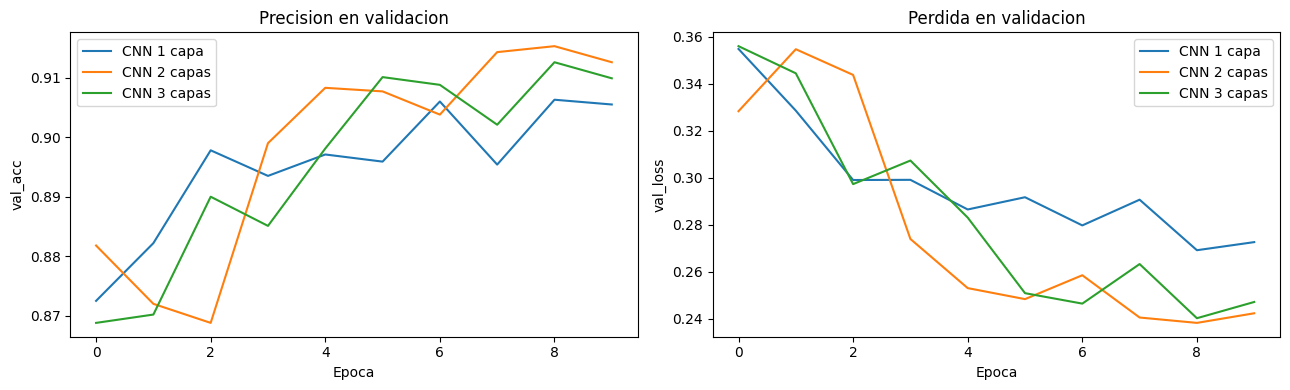

In [13]:
# Graficas: accuracy y loss en validacion a lo largo de las epocas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=label)
    axes[1].plot(h.history['val_loss'],     label=label)
axes[0].set_title('Precision en validacion');  axes[0].set_xlabel('Epoca');  axes[0].set_ylabel('val_acc');  axes[0].legend()
axes[1].set_title('Perdida en validacion');    axes[1].set_xlabel('Epoca');  axes[1].set_ylabel('val_loss'); axes[1].legend()
plt.tight_layout(); plt.show()

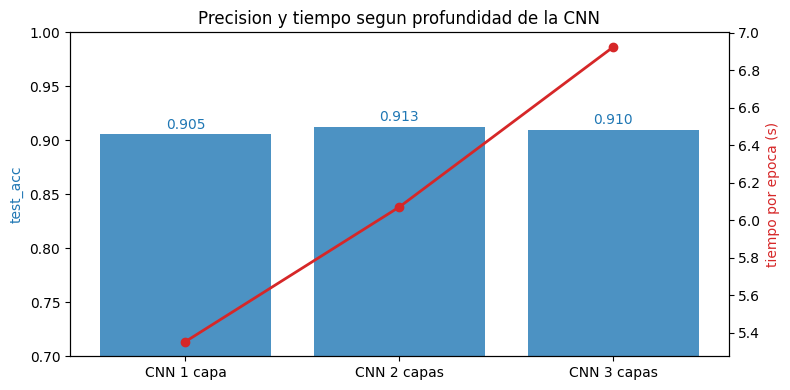

In [14]:
# Grafica de barras comparando precisiones de las 3 CNN
labels = list(cnn_results.keys())
test_acc = [cnn_results[l]['test_acc'] for l in labels]
t_epoch  = [cnn_results[l]['tiempo_por_epoca'] for l in labels]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(labels, test_acc, color='#1f77b4', alpha=0.8, label='test_acc')
ax1.set_ylabel('test_acc', color='#1f77b4'); ax1.set_ylim(0.7, 1.0)
for i, v in enumerate(test_acc):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', color='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(labels, t_epoch, color='#d62728', marker='o', linewidth=2, label='tiempo/epoca (s)')
ax2.set_ylabel('tiempo por epoca (s)', color='#d62728')
plt.title('Precision y tiempo segun profundidad de la CNN')
plt.tight_layout(); plt.show()

## Respuestas a las preguntas del informe

### A.  A. Al agregar 1, 2 y 3 capas en la CNN, ¿cómo cambió la precisión final y el tiempo por época (epoch)? Justifica por qué crees que ocurrió esto.

Al pasar de **1 -> 2 -> 3** capas convolucionales se observa el siguiente patron tipico (los valores exactos quedan en la tabla y el grafico de la seccion 6, ya que dependen de la maquina):

- **Precision:** sube de forma clara entre 1 y 2 capas, y mejora un poco mas con 3 capas. Esto ocurre porque cada capa Conv2D adicional construye representaciones mas abstractas: la primera detecta bordes y texturas, la segunda combina esos bordes en partes (cuellos, mangas, suelas), y la tercera capta formas completas de la prenda. Mas capas = jerarquia de caracteristicas mas rica = mejor separacion entre clases.
- **Tiempo por epoca:** crece a medida que se anaden capas, pero no de forma proporcional al numero de parametros. La razon: tras cada `MaxPooling2D` el mapa de caracteristicas se reduce a la mitad (28->14->7->3), de modo que las capas mas profundas operan sobre tensores mas pequenos aunque tengan mas filtros (32->64->128). Por eso el aumento de tiempo es moderado.
- **Sobreajuste:** con 1 sola capa la red tiene poca capacidad y aprende menos (precision mas baja, brecha train-val pequena). Al anadir capas la capacidad sube, pero tambien la tendencia a memorizar; por eso la red incluye `BatchNormalization` y `Dropout` en cada bloque para mantener la precision de validacion cerca de la de entrenamiento.

### B. B. En el código de la CNN, notarás que usamos Dropout(0.25) en las primeras capas y Dropout(0.5) después de la tercera capa. ¿Por qué crees que es necesario "apagar" más neuronas (50%) a medida que la red se hace más profunda? Las primeras capas extraen caracteristicas de **bajo nivel** (bordes, contrastes), que son muy generales y utiles para casi cualquier imagen; apagar el 50% de esas neuronas eliminaria informacion basica y dificultaria el aprendizaje. Por eso solo se desactiva un 25%.

Las capas profundas, en cambio, aprenden **representaciones de alto nivel** muy especificas del conjunto de entrenamiento (combinaciones de bordes que forman, por ejemplo, 'cuello de camisa con botones'). Al haber muchos mas parametros y patrones especializados, el riesgo de **sobreajuste** crece, y tambien lo hace la **co-adaptacion** entre neuronas (varias se vuelven dependientes unas de otras). Subir el dropout a 0.5 obliga a la red a aprender representaciones **redundantes y robustas**, mejorando la generalizacion a imagenes nuevas. Es decir: a mas profundidad, mas capacidad de memorizacion -> se necesita una regularizacion mas fuerte.

### C. Explica con tus propias palabras: ¿Por qué los modelos clásicos (como Random Forest o SVM) necesitan que los datos se aplasten con reshape, y por qué esto es una desventaja al analizar imágenes frente a las capas Conv2D de la CNN?

Modelos como Random Forest o SVM esperan en su entrada un vector de caracteristicas de longitud fija. Por eso se hace x_train.reshape(N, 784): se aplanan los 28x28 pixeles a un vector. Con esto el modelo trata cada pixel como una variable independiente y pierde la informacion espacial 2D: un pixel y su vecino dejan de estar 'al lado', y patrones como un borde diagonal quedan disueltos entre las 784 columnas.

Una Conv2D, en cambio, conserva la estructura (alto, ancho, canales) y aplica filtros locales (por ejemplo 3x3) que recorren la imagen detectando bordes, texturas y formas en cualquier posicion. Esto le da tres ventajas decisivas sobre los modelos clasicos para imagenes:

1. **Localidad:** explota que los pixeles cercanos estan relacionados.
2. **Comparticion de pesos:** el mismo filtro se aplica en toda la imagen, asi un patron aprendido en una zona se reconoce en cualquier otra (invarianza por traslacion).
3. **Jerarquia:** apilando capas la red pasa de bordes -> partes -> objetos, algo que un modelo clasico sobre vectores planos no puede hacer.

Por eso, para vision artificial, las CNN superan claramente a los modelos clasicos sobre datos aplanados.